# Ostium accuracy & centerline precision: ASOCA vs MACS-18

Grouped bar chart comparing **ostium accuracy** (OISR) and **centerline precision** (CESR) between cohorts.

**Data:** hardcoded from `TFG Results v2.md` (MACS-18 §1.3–1.4, ASOCA §1.3–1.4).

**Colors:** ASOCA = blue, MACS-18 = orange (same as `visualizations_02_endpoints_comparison.ipynb`).

**Exports:** `exports/fig_ostium_centerline_metrics.png`, `exports/metrics_ostium_centerline_comparison.csv`

## 1. Setup

In [1]:
from __future__ import annotations

import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "src" / "blocks" / "_01_extraction.py").is_file():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError(
            "Could not locate repo root. Run Jupyter from the repo or from "
            "notebooks/results visualizations."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPORT_DIR = NOTEBOOK_DIR / "exports"
THESIS_FIG_DIR = PROJECT_ROOT / "thesis" / "TFG_Latex2526" / "figures"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
THESIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

COLOR_ASOCA = "#3182bd"
COLOR_MACS = "#e6550d"
BAR_ALPHA = 0.88

METRIC_LABELS = {
    "ostium_accuracy_pct": "Ostium accuracy",
    "centerline_precision_pct": "Centerline precision",
}

print(f"Exports : {EXPORT_DIR}")

Exports : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports


## 2. Hardcoded metrics (`TFG Results v2`)

| Cohort | Metric | All | Normal | Diseased |
|--------|--------|-----|--------|----------|
| MACS-18 | Ostium (OISR) | 73.75% | 75.00% | 72.50% |
| MACS-18 | Centerline (CESR) | 95.62% | 96.87% | 94.04% |
| ASOCA | Ostium (OISR) | 85.00% | 85.00% | 85.00% |
| ASOCA | Centerline (CESR) | 83.19% | 83.18% | 83.21% |

In [2]:
# MACS-18 — section 1.3 (OISR) and 1.4 (CESR)
METRICS_MACS_18: dict[str, dict[str, float]] = {
    "ostium_accuracy_pct": {"All": 73.75, "Normal": 75.00, "Diseased": 72.50},
    "centerline_precision_pct": {"All": 95.62, "Normal": 96.87, "Diseased": 94.04},
}

# ASOCA — section 1.3 (OISR) and 1.4 (CESR)
METRICS_ASOCA: dict[str, dict[str, float]] = {
    "ostium_accuracy_pct": {"All": 85.00, "Normal": 85.00, "Diseased": 85.00},
    "centerline_precision_pct": {"All": 83.19, "Normal": 83.18, "Diseased": 83.21},
}


def build_metrics_table(
    metrics_asoca: dict[str, dict[str, float]],
    metrics_macs: dict[str, dict[str, float]],
) -> pd.DataFrame:
    """Long table: Cohort × Subgroup × metric columns (%)."""
    rows: list[dict] = []
    for cohort, block in (("ASOCA", metrics_asoca), ("MACS-18", metrics_macs)):
        for subgroup in ("All", "Normal", "Diseased"):
            rows.append(
                {
                    "Cohort": cohort,
                    "Subgroup": subgroup,
                    "Ostium accuracy (%)": block["ostium_accuracy_pct"][subgroup],
                    "Centerline precision (%)": block["centerline_precision_pct"][subgroup],
                }
            )
    return pd.DataFrame(rows)


df_metrics = build_metrics_table(METRICS_ASOCA, METRICS_MACS_18)
display(df_metrics)

,Cohort,Subgroup,Ostium accuracy (%),Centerline precision (%)
0,ASOCA,All,85.00,83.19
1,ASOCA,Normal,85.00,83.18
2,ASOCA,Diseased,85.00,83.21
3,MACS-18,All,73.75,95.62
4,MACS-18,Normal,75.00,96.87
5,MACS-18,Diseased,72.50,94.04


## 3. Grouped bar plot (cohort totals: All patients)

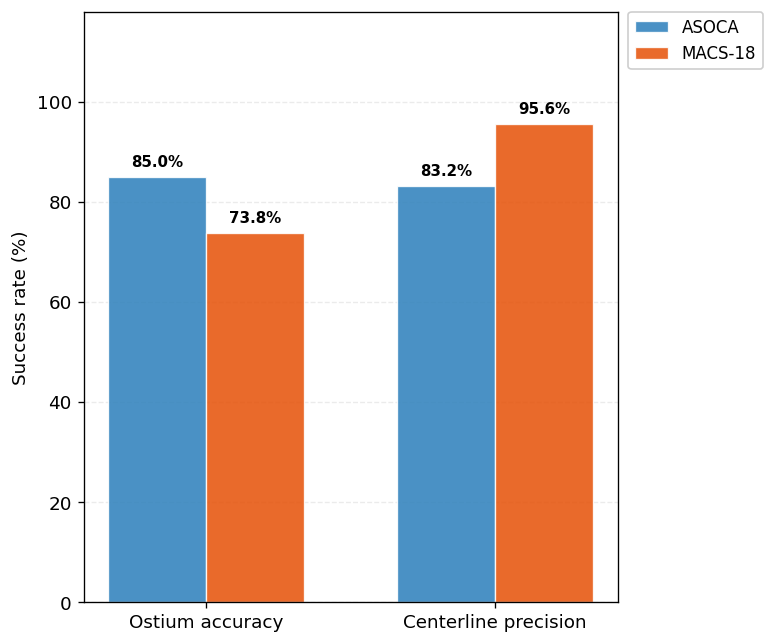

In [4]:
def plot_ostium_centerline_bars(
    metrics_asoca: dict[str, dict[str, float]],
    metrics_macs: dict[str, dict[str, float]],
    *,
    subgroup: str = "All",
    figsize: tuple[float, float] = (8.5, 5.5),
):
    metric_keys = list(METRIC_LABELS.keys())
    x_labels = [METRIC_LABELS[k] for k in metric_keys]
    x = np.arange(len(metric_keys))
    bar_width = 0.34

    asoca_vals = [metrics_asoca[k][subgroup] for k in metric_keys]
    macs_vals = [metrics_macs[k][subgroup] for k in metric_keys]

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(
        x - bar_width / 2,
        asoca_vals,
        bar_width,
        label="ASOCA",
        color=COLOR_ASOCA,
        alpha=BAR_ALPHA,
        edgecolor="white",
        linewidth=0.8,
    )
    ax.bar(
        x + bar_width / 2,
        macs_vals,
        bar_width,
        label="MACS-18",
        color=COLOR_MACS,
        alpha=BAR_ALPHA,
        edgecolor="white",
        linewidth=0.8,
    )

    for i, (va, vm) in enumerate(zip(asoca_vals, macs_vals)):
        ax.text(
            x[i] - bar_width / 2,
            va + 1.5,
            f"{va:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            weight="bold",
        )
        ax.text(
            x[i] + bar_width / 2,
            vm + 1.5,
            f"{vm:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            weight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Success rate (%)")
    ax.set_ylim(0, 118)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        framealpha=0.95,
    )
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    fig.subplots_adjust(left=0.10, right=0.72, top=0.95, bottom=0.14)
    return fig, ax


_preview_fig, _ = plot_ostium_centerline_bars(METRICS_ASOCA, METRICS_MACS_18, subgroup="All")
_buf = io.BytesIO()
_preview_fig.savefig(_buf, format="png", dpi=120)
_buf.seek(0)
display(Image(data=_buf.read()))
plt.close(_preview_fig)

## 4. Export figure and table

In [5]:
FIG_STEM = "fig_ostium_centerline_metrics"
CSV_NAME = "metrics_ostium_centerline_comparison.csv"

fig_path_nb = EXPORT_DIR / f"{FIG_STEM}.png"
fig_path_tex = THESIS_FIG_DIR / f"{FIG_STEM}.png"
csv_path = EXPORT_DIR / CSV_NAME

fig, _ = plot_ostium_centerline_bars(METRICS_ASOCA, METRICS_MACS_18, subgroup="All")
fig.savefig(fig_path_nb, dpi=300)
fig.savefig(fig_path_tex, dpi=300)
plt.close(fig)

df_metrics.to_csv(csv_path, index=False)

print(f"Saved figure: {fig_path_nb}")
print(f"Saved figure: {fig_path_tex}")
print(f"Saved table : {csv_path}")

Saved figure: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\fig_ostium_centerline_metrics.png
Saved figure: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\thesis\TFG_Latex2526\figures\fig_ostium_centerline_metrics.png
Saved table : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\metrics_ostium_centerline_comparison.csv
